In [6]:
from pathlib import Path
import scanpy as sc
# Info
whatFer = "one" # "one" or  "two"

#Load data
#So .X is log1p(CP1e6) (CPM-style per-million normalization, then log1p)
base_folder = Path(f"/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/CellCharterAnalysis/{whatFer}fer/")
adata_file  = base_folder / "adata_mac_annotated.h5ad"
lr_results  = base_folder / "lr_all_results.h5ad"


adata = sc.read_h5ad(adata_file)
lr_all = sc.read_h5ad(lr_results)

# Incorporating spp1 cd44

In [7]:
## import re
import numpy as np
import pandas as pd
from scipy import sparse

# --- find the Spp1|Cd44 interaction column in lr_all ---
lig_col = 'ligand' if 'ligand' in lr_all.var.columns else None
rec_col = 'receptor' if 'receptor' in lr_all.var.columns else None

hits = []
if lig_col and rec_col:
    mask = (lr_all.var[lig_col].str.lower() == 'spp1') & (lr_all.var[rec_col].str.lower() == 'cd44')
    hits = lr_all.var_names[mask].tolist()
if not hits:
    pat = re.compile(r'^spp1\|cd44$', flags=re.IGNORECASE)
    hits = [v for v in lr_all.var_names if pat.match(v)]
assert len(hits) >= 1, "Spp1|Cd44 interaction not found in lr_all.var/var_names"
i_name = hits[0]
j = list(lr_all.var_names).index(i_name)
print(f"Using interaction: {i_name} @ column {j}")

# --- pull local scores from lr_all and map onto adata.obs_names ---
xcol = lr_all.X[:, j].toarray().ravel() if sparse.issparse(lr_all.X) else np.asarray(lr_all.X).ravel()[::lr_all.n_vars*0+1]  # safe 1D
scores = pd.Series(xcol, index=lr_all.obs_names, name="LR_Spp1_Cd44")

# align to adata (missing cells -> NaN)
adata.obs["LR_Spp1_Cd44"] = scores.reindex(adata.obs_names).values
adata.obs["LR_Spp1_Cd44"].head()


Using interaction: Spp1^Cd44 @ column 145


ID_100000    0.000000
ID_100001    0.000000
ID_100005    0.000000
ID_100006    0.000000
ID_100007    0.101806
Name: LR_Spp1_Cd44, dtype: float32

## Defining spp1 high and high lr macrophages

In [8]:
# --- params ---
quantile_hi = 0.80          # keep your high cut at the 80th percentile
quantile_lo = 0.20          # low = bottom 20% of POSITIVE (>0) scores
prefix = ""

mac_col   = f"{prefix}Mac_like_tiered"
spp1_col  = f"{prefix}Spp1_pos"
mouse_key = "mouse"
score_col = "LR_Spp1_Cd44"

for c in (mac_col, spp1_col, score_col, mouse_key):
    assert c in adata.obs.columns, f"Missing {c}"

obs = adata.obs[[mac_col, spp1_col, score_col, mouse_key]].copy()
obs["is_mac"] = obs[mac_col].astype(bool).values
obs["is_spp1pos"] = obs[spp1_col].astype(int).values == 1

# per-mouse thresholds
thr_hi, thr_lo = {}, {}
for m, dfm in obs.groupby(mouse_key):
    sel_all = dfm["is_mac"] & dfm["is_spp1pos"] & np.isfinite(dfm[score_col])
    sel_pos = sel_all & (dfm[score_col] > 0)

    # high threshold (unchanged): 80th among ALL Spp1+ macs (zeros included)
    thr_hi[m] = dfm.loc[sel_all, score_col].quantile(quantile_hi) if sel_all.any() else np.nan

    # low threshold: 20th among POSITIVE (>0) scores only
    thr_lo[m] = dfm.loc[sel_pos, score_col].quantile(quantile_lo) if sel_pos.any() else np.nan

def tier_row(row):
    if not (row["is_mac"] and row["is_spp1pos"] and np.isfinite(row[score_col])):
        return "NA"  # not in the Spp1+ mac set or missing score
    s = row[score_col]
    if s == 0:
        return "zero"  # zeros explicitly excluded from "low"
    hi = thr_hi.get(row[mouse_key], np.nan)
    lo = thr_lo.get(row[mouse_key], np.nan)
    if np.isfinite(hi) and s >= hi:
        return "high"
    if np.isfinite(lo) and s < lo:
        return "low"
    return "med"

adata.obs["Mac_Spp1pos_LR_tier"] = obs.apply(tier_row, axis=1).astype("category")

# keep your original boolean (high vs rest)
adata.obs["Mac_Spp1pos_highLR"] = (adata.obs["Mac_Spp1pos_LR_tier"] == "high").astype(int)

# optional helper booleans if you want them:
adata.obs["Mac_Spp1pos_lowLR"]  = (adata.obs["Mac_Spp1pos_LR_tier"] == "low").astype(int)
adata.obs["Mac_Spp1pos_medLR"]  = (adata.obs["Mac_Spp1pos_LR_tier"] == "med").astype(int)
adata.obs["Mac_Spp1pos_zeroLR"] = (adata.obs["Mac_Spp1pos_LR_tier"] == "zero").astype(int)

# quick counts
print("Tier counts (Spp1+ macrophages only):")
print(adata.obs["Mac_Spp1pos_LR_tier"].value_counts(dropna=False).to_string())


/tmp/ipykernel_11949/4046553660.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for m, dfm in obs.groupby(mouse_key):


Tier counts (Spp1+ macrophages only):
Mac_Spp1pos_LR_tier
NA      154220
med       8855
high      3115
low       2996
zero       587


# Stacked Barchart

## Testing

In [9]:
adata

AnnData object with n_obs × n_vars = 169773 × 16794
    obs: 'id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mouse', 'sample_id', 'condition', 'cx', 'cy', 'TMA', 'library_id', 'n_counts', '_scvi_batch', '_scvi_labels', 'cluster_cellcharter', 'tumor_loc', 'M1_core_n', 'M1_acc_n', 'M2_core_n', 'M2_acc_n', 'M1_total', 'M2_total', 'M1_score_tiered', 'M2_score_tiered', 'Mac_polarization_tiered', 'Mac_like_tiered', 'Spp1_pos', 'Glp1r_pos', 'Mac_Spp1_pos', 'Mac_Glp1r_pos', 'Mac_marker_combo', 'LR_Spp1_Cd44', 'Mac_Spp1pos_LR_tier', 'Mac_Spp1pos_highLR', 'Mac_Spp1pos_lowLR', 'Mac_Spp1pos_medLR', 'Mac_Spp1pos_zeroLR'
    var: 'n_counts'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cluster_cellcharter_colors', 'condition_colors', 'log1p', 'spatial', 'spatial_neighbors'
    obsm: 'X_cellcharter', 'X_scVI', 'spatial'
    layers: 'co

In [10]:
adata.obs['Mac_Spp1pos_highLR'].describe()

count    169773.000000
mean          0.018348
std           0.134207
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: Mac_Spp1pos_highLR, dtype: float64

In [17]:
test_adata = adata[adata.obs['mouse'] == "RTCyT72_2_1"].copy()

In [18]:
test_adata.obs['Mac_polarization_tiered'].unique()

['Neither', 'M2', 'M1']
Categories (3, object): ['M1', 'M2', 'Neither']

In [19]:
required_columns = [
    'Mac_polarization_tiered',
    'Mac_Spp1pos_highLR'
]

In [20]:
['mouse', *required_columns]

['mouse', 'Mac_polarization_tiered', 'Mac_Spp1pos_highLR']

In [21]:
labels = ['M1', 'M2']

In [22]:
test_obs = test_adata.obs[['mouse', *required_columns]].copy()

In [23]:
summary = (test_obs.groupby("Mac_polarization_tiered")
           .agg(total=("Mac_polarization_tiered", "size"), m2_m2_Hsp1=('Mac_Spp1pos_highLR', lambda s:(s==1).sum()))
           .reset_index()
          )
summary

/tmp/ipykernel_11949/2003255188.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = (test_obs.groupby("Mac_polarization_tiered")


,Mac_polarization_tiered,total,m2_m2_Hsp1
0,M1,283,28
1,M2,249,39
2,Neither,17046,0


# Looping

In [27]:
adata.obs['Mac_polarization_tiered'].unique()

['Neither', 'M2', 'M1', 'Both']
Categories (4, object): ['M1', 'M2', 'Both', 'Neither']

In [26]:
adata.obs['mouse'].unique()

['RTCyT72_2_1', 'RTCyPSCA_1_4', 'CyPSCA_1_1', 'NoTx_2_2', 'CyPSCA_1_2', 'RTCyT72_2_4', 'RTCyPSCA_2_4', 'CyT72_1_4']
Categories (8, object): ['CyPSCA_1_1', 'CyPSCA_1_2', 'CyT72_1_4', 'NoTx_2_2', 'RTCyPSCA_1_4', 'RTCyPSCA_2_4', 'RTCyT72_2_1', 'RTCyT72_2_4']

/tmp/ipykernel_11949/2913454775.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  denom = g.groupby(mouse_key)["total"].sum().rename("denom")
/tmp/ipykernel_11949/2913454775.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  denom = g.groupby(mouse_key)["total"].sum().rename("denom")
/tmp/ipykernel_11949/2913454775.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  denom = g.groupby(mouse_key)["total"].sum().renam

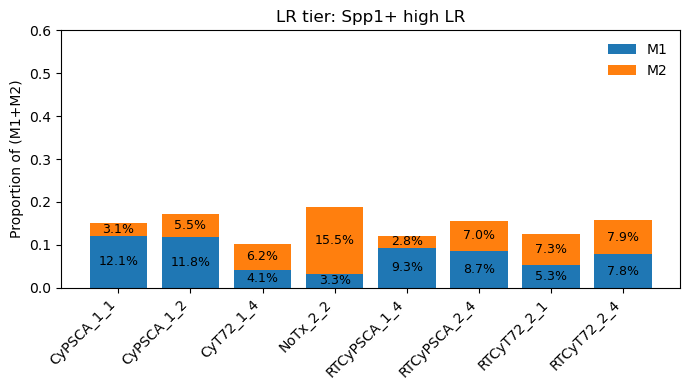

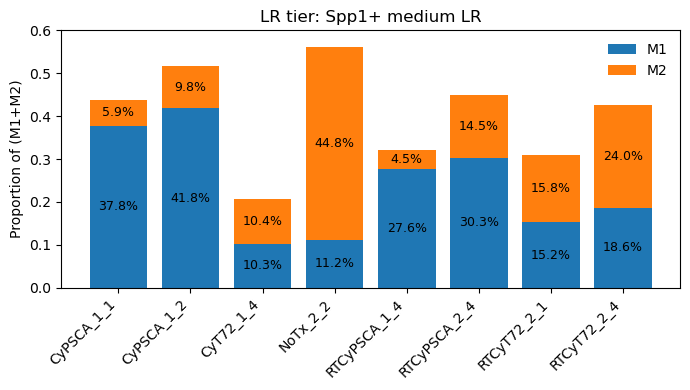

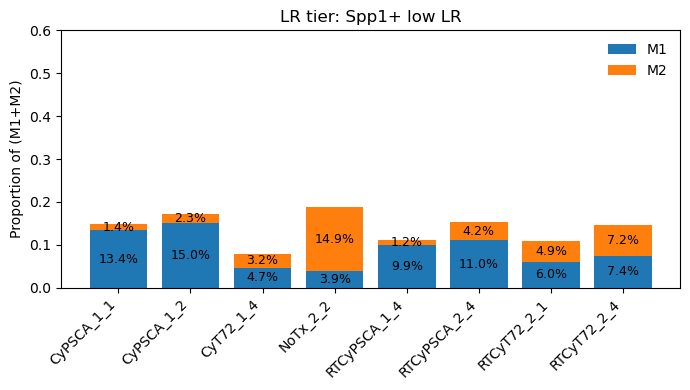

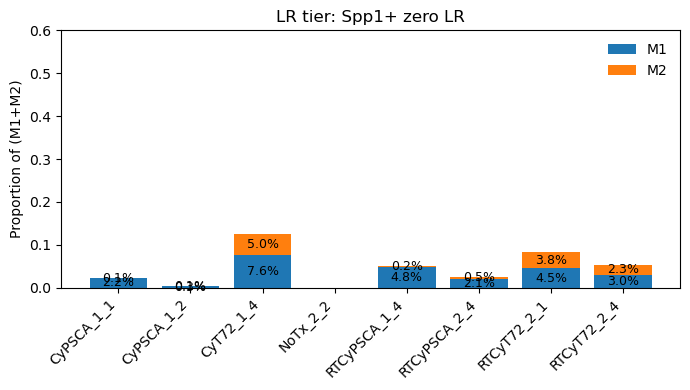

In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- config (adjust these two if your column names differ) ---
mouse_key     = "mouse"
mac_tier_col  = "Mac_polarization_tiered"   # column with "M1"/"M2" labels
tier_cols = {
    "Mac_Spp1pos_highLR": "Spp1+ high LR",
    "Mac_Spp1pos_medLR":  "Spp1+ medium LR",
    "Mac_Spp1pos_lowLR":  "Spp1+ low LR",
    "Mac_Spp1pos_zeroLR": "Spp1+ zero LR",
}
# optional: where to save figures
outdir = r"/mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/Results/spp1_mac_analysis/final_analysi"
os.makedirs(outdir, exist_ok=True)

# keep only columns we need once
need = [mouse_key, mac_tier_col] + list(tier_cols.keys())
obs2 = adata.obs[need].copy()

# -------------------------------------------------------------------------
def build_plot_df(mask_col: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Returns:
      plot_df: wide (index=mouse, columns=["M1","M2"]) with proportions of positives out of (M1+M2)
      wide_counts: wide table with ("total"|"pos") x ("M1"|"M2") counts
    """
    sub = obs2[obs2[mac_tier_col].isin(["M1", "M2"])].copy()

    # totals per mouse x tier (denominator = M1_total + M2_total per mouse)
    totals = (sub.groupby([mouse_key, mac_tier_col], observed=True)
                .size().rename("total").reset_index())

    # positives per mouse x tier for the requested LR mask
    pos = (sub[sub[mask_col] == 1]
           .groupby([mouse_key, mac_tier_col], observed=True)
           .size().rename("pos").reset_index())

    g = totals.merge(pos, on=[mouse_key, mac_tier_col], how="left").fillna({"pos": 0})
    g["pos"] = g["pos"].astype(int)

    # denominator per mouse
    denom = g.groupby(mouse_key)["total"].sum().rename("denom")
    g = g.merge(denom, on=mouse_key, how="left")
    g["p"] = g["pos"] / g["denom"].where(g["denom"] != 0, 1)

    wide_counts = (g.pivot(index=mouse_key, columns=mac_tier_col, values=["total", "pos"])
                     .reindex(columns=pd.MultiIndex.from_product([["total","pos"], ["M1","M2"]]))
                     .fillna(0).astype(int))

    plot_df = (g.pivot(index=mouse_key, columns=mac_tier_col, values="p")
                 .reindex(columns=["M1", "M2"], fill_value=0.0))
    return plot_df, wide_counts


def plot_stack(plot_df: pd.DataFrame, wide_counts: pd.DataFrame, title: str, savepath: str | None = None):
    labels = plot_df.index.to_list()
    p_m1 = plot_df["M1"].to_numpy() if "M1" in plot_df.columns else np.zeros(len(labels))
    p_m2 = plot_df["M2"].to_numpy() if "M2" in plot_df.columns else np.zeros(len(labels))

    x = np.arange(len(labels))
    fig, ax = plt.subplots(figsize=(7, 4))

    bars_m1 = ax.bar(x, p_m1, label="M1")
    bars_m2 = ax.bar(x, p_m2, bottom=p_m1, label="M2")

    ax.set_xticks(x, labels, rotation=45, ha="right")
    ax.set_ylim(0, 0.6)  # proportions of (M1+M2)
    ax.set_ylabel("Proportion of (M1+M2)")
    ax.set_title(title)
    ax.legend(loc="upper right", frameon=False)

    # annotate % inside each segment
    for bars, vals, bottoms in [(bars_m1, p_m1, np.zeros_like(p_m1)),
                                (bars_m2, p_m2, p_m1)]:
        for i, b in enumerate(bars):
            h = b.get_height()
            if h <= 0: 
                continue
            ax.text(b.get_x() + b.get_width()/2, bottoms[i] + h/2,
                    f"{vals[i]*100:.1f}%", ha="center", va="center", fontsize=9)

    # total N above each bar
    N = wide_counts["total"]["M1"].add(wide_counts["total"]["M2"], fill_value=0).astype(int)
    # for i, n in enumerate(N.reindex(labels).to_numpy()):
    #     ax.text(x[i], 1.02, f"N={int(n)}", ha="center", va="bottom", fontsize=9)

    # white background
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    plt.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight", facecolor="white", edgecolor="none")
        # plt.close(fig)  # uncomment if generating many figures

    return fig, ax
# -------------------------------------------------------------------------

# Build and plot all tiers
for col, nice in tier_cols.items():
    plot_df, wide_counts = build_plot_df(col)
    fname = os.path.join(outdir, f"spp1_mac_composition_{col}.png")
    plot_stack(plot_df, wide_counts, f"LR tier: {nice}", savepath=fname)


# Updated Code:

/tmp/ipykernel_11949/2349721799.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  denom_per_mouse = g.groupby([mouse_key, "mouse_group"])["total"].sum().rename("denom").reset_index()
/tmp/ipykernel_11949/2349721799.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  denom_per_mouse = g.groupby([mouse_key, "mouse_group"])["total"].sum().rename("denom").reset_index()
/tmp/ipykernel_11949/2349721799.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future def

(<Figure size 1000x480 with 1 Axes>,
 <Axes: title={'center': 'Spp1+ LR tiers within M1 and within M2 (averaged groups)'}, ylabel='Proportion of (M1 + M2)'>)

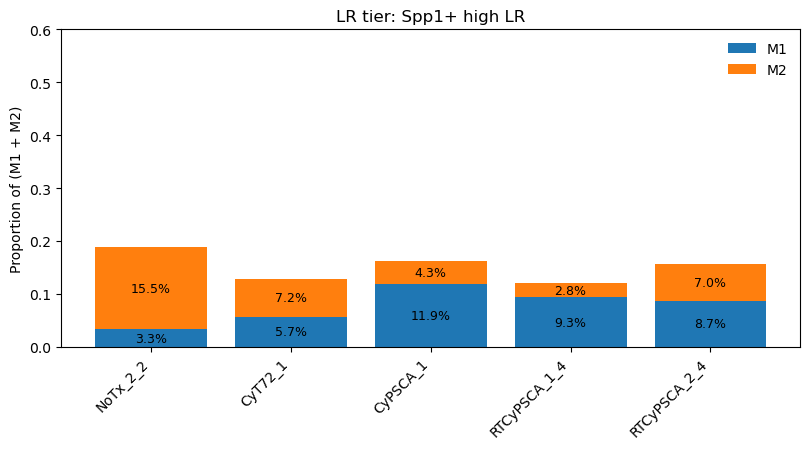

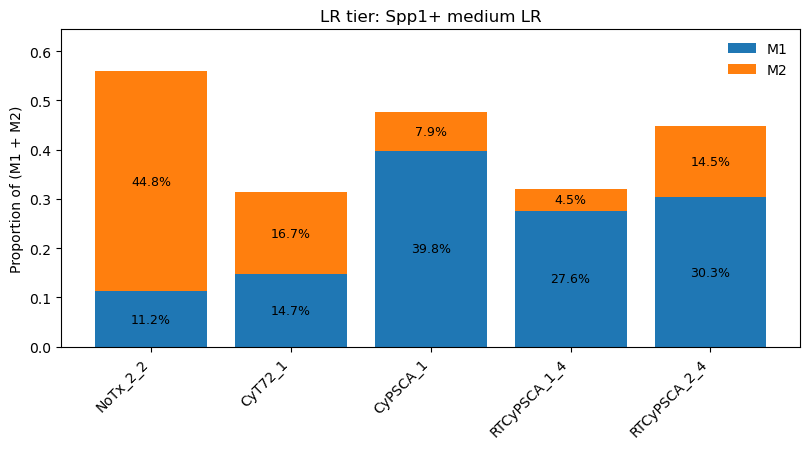

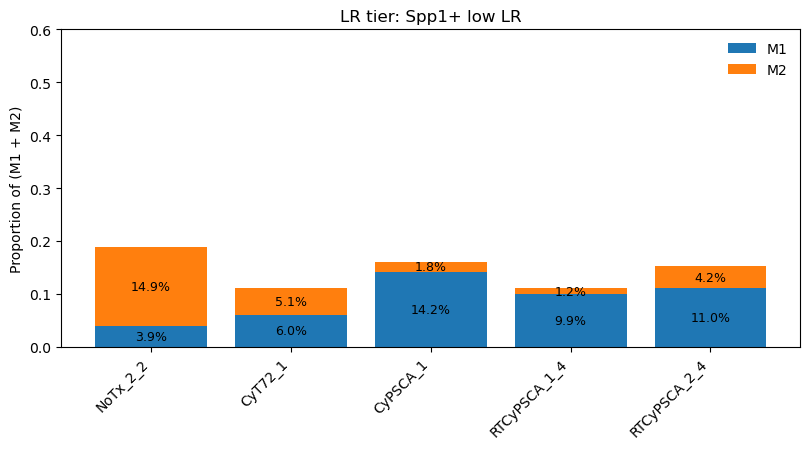

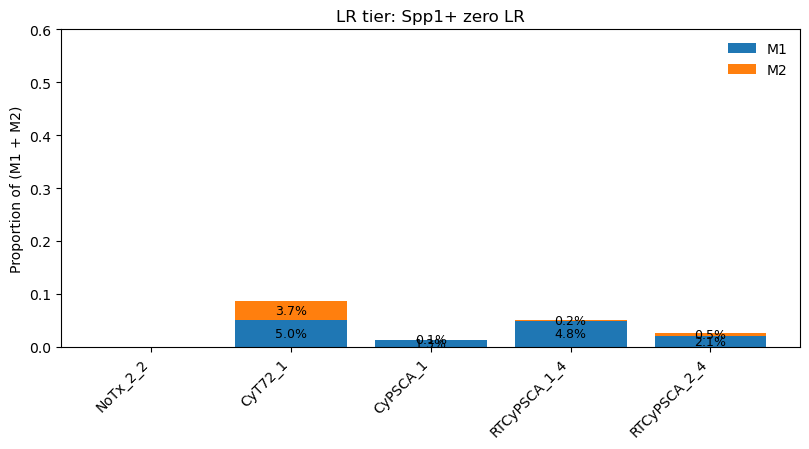

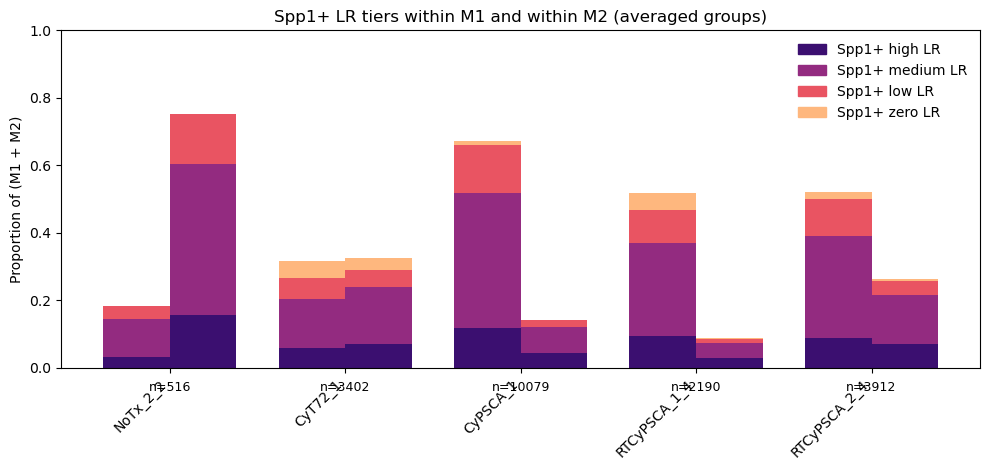

In [51]:
# ## Looping (revised)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

# --- config (adjust these two if your column names differ) ---
mouse_key     = "mouse"
mac_tier_col  = "Mac_polarization_tiered"   # column with "M1"/"M2" labels
tier_cols = {
    "Mac_Spp1pos_highLR": "Spp1+ high LR",
    "Mac_Spp1pos_medLR":  "Spp1+ medium LR",
    "Mac_Spp1pos_lowLR":  "Spp1+ low LR",
    "Mac_Spp1pos_zeroLR": "Spp1+ zero LR",
}
# use the same output directory defined earlier in your script: `outdir`

# --- grouping/renaming for averaging ---
group_map = {
    "CyPSCA_1_1":   "CyPSCA_1",
    "CyPSCA_1_2":   "CyPSCA_1",
    "RTCyT72_2_1":  "CyT72_1",
    "RTCyT72_2_4":  "CyT72_1",
    "CyT72_1_4":     "CyT72_1",
    # pass-through (keep original names)
    "NoTx_2_2":      "NoTx_2_2",
    # "CyT72_1_4":     "CyT72_1_4",
    "RTCyPSCA_1_4":  "RTCyPSCA_1_4",
    "RTCyPSCA_2_4":  "RTCyPSCA_2_4",
}
desired_order = ["NoTx_2_2", "CyT72_1", "CyPSCA_1", "RTCyPSCA_1_4", "RTCyPSCA_2_4"]

# keep only columns we need once
need = [mouse_key, mac_tier_col] + list(tier_cols.keys())
obs2 = adata.obs[need].copy()

# attach group labels for averaging
obs2["mouse_group"] = obs2[mouse_key].map(group_map).fillna(obs2[mouse_key])

# -------------------------------------------------------------------------
def build_plot_df(mask_col: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    For a given LR mask (e.g., 'Mac_Spp1pos_highLR'):
      1) compute per-mouse proportions for M1 and M2 relative to (M1+M2)
      2) average those proportions within mouse_group (simple mean of per-mouse percentages)
      3) return plot_df (rows mouse_group, cols ['M1','M2']) and counts (summed totals/positives per group)
    """
    sub = obs2[obs2[mac_tier_col].isin(["M1", "M2"])].copy()

    # per-mouse totals (denominator) and positives for the requested LR mask
    totals = (sub.groupby([mouse_key, "mouse_group", mac_tier_col], observed=True)
                .size().rename("total").reset_index())
    pos = (sub[sub[mask_col] == 1]
           .groupby([mouse_key, "mouse_group", mac_tier_col], observed=True)
           .size().rename("pos").reset_index())

    g = totals.merge(pos, on=[mouse_key, "mouse_group", mac_tier_col], how="left").fillna({"pos": 0})
    g["pos"] = g["pos"].astype(int)

    # denominator per (mouse) = M1_total + M2_total for that mouse
    denom_per_mouse = g.groupby([mouse_key, "mouse_group"])["total"].sum().rename("denom").reset_index()
    g = g.merge(denom_per_mouse, on=[mouse_key, "mouse_group"], how="left")
    g["p"] = g["pos"] / g["denom"].where(g["denom"] != 0, 1)

    # --- average proportions within group (simple mean of per-mouse p) ---
    p_group = (g.groupby(["mouse_group", mac_tier_col], observed=True)["p"]
                 .mean().rename("p_mean").reset_index())

    # arrange wide for plotting
    plot_df = (p_group.pivot(index="mouse_group", columns=mac_tier_col, values="p_mean")
                      .reindex(columns=["M1", "M2"], fill_value=0.0))

    # counts table (sum across mice in the group)
    counts_group = (g.groupby(["mouse_group", mac_tier_col], observed=True)[["total", "pos"]]
                      .sum().astype(int).reset_index())
    wide_counts = (counts_group.pivot(index="mouse_group", columns=mac_tier_col, values=["total", "pos"])
                              .reindex(columns=pd.MultiIndex.from_product([["total","pos"], ["M1","M2"]]))
                              .fillna(0).astype(int))
    return plot_df, wide_counts


def plot_stack_m1m2(plot_df: pd.DataFrame, wide_counts: pd.DataFrame, title: str, savepath: str | None = None):
    labels = [lab for lab in desired_order if lab in plot_df.index]
    plot_df = plot_df.reindex(labels)

    p_m1 = plot_df["M1"].to_numpy() if "M1" in plot_df.columns else np.zeros(len(labels))
    p_m2 = plot_df["M2"].to_numpy() if "M2" in plot_df.columns else np.zeros(len(labels))

    x = np.arange(len(labels))
    fig, ax = plt.subplots(figsize=(8.2, 4.6))

    bars_m1 = ax.bar(x, p_m1, label="M1")
    bars_m2 = ax.bar(x, p_m2, bottom=p_m1, label="M2")

    ax.set_xticks(x, labels, rotation=45, ha="right")
    ax.set_ylim(0, max(0.6, (p_m1 + p_m2).max() * 1.15))
    ax.set_ylabel("Proportion of (M1 + M2)")
    ax.set_title(title)
    ax.legend(loc="upper right", frameon=False)

    # annotate % in each segment
    for bars, vals, bottoms in [(bars_m1, p_m1, np.zeros_like(p_m1)),
                                (bars_m2, p_m2, p_m1)]:
        for i, b in enumerate(bars):
            h = b.get_height()
            if h <= 0:
                continue
            ax.text(b.get_x() + b.get_width()/2, bottoms[i] + h/2,
                    f"{vals[i]*100:.1f}%", ha="center", va="center", fontsize=9)

    # white background
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    plt.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight", facecolor="white", edgecolor="none")
    return fig, ax
# -------------------------------------------------------------------------

# ----- FIGURE SET 1: For each LR tier separately (M1 stacked under M2), after averaging pairs -----
for col, nice in tier_cols.items():
    plot_df, wide_counts = build_plot_df(col)
    # enforce order for plotting
    plot_df = plot_df.reindex(desired_order).dropna(how="all")
    wide_counts = wide_counts.reindex(desired_order)
    fname = os.path.join(outdir, f"spp1_mac_composition_{col}.png")
    plot_stack_m1m2(plot_df, wide_counts, f"LR tier: {nice}", savepath=fname)

# -------------------------------------------------------------------------
# ----- FIGURE SET 2: Within each of M1 and M2, stack the LR tiers (magma palette) -----

def build_LR_stack_df() -> tuple[pd.DataFrame, pd.Series]:
    """
    Returns:
      stacked_df: index (mouse_group, mac_tier in ['M1','M2']), columns=LR keys
                  values are proportions relative to (M1+M2) (consistent with Fig 1)
      N_group: total macrophage count (M1+M2) summed across mice within the group
    """
    sub = obs2[obs2[mac_tier_col].isin(["M1", "M2"])].copy()

    # totals per (mouse, group, mac_tier)
    totals = (sub.groupby([mouse_key, "mouse_group", mac_tier_col], observed=True)
                .size().rename("total").reset_index())
    denom_per_mouse = totals.groupby([mouse_key, "mouse_group"])["total"].sum().rename("denom").reset_index()

    # LR tier long table of positives per (mouse, group, mac_tier, lr_key)
    parts = []
    for lr_key in tier_cols.keys():
        pos = (sub[sub[lr_key] == 1]
               .groupby([mouse_key, "mouse_group", mac_tier_col], observed=True)
               .size().rename("pos").reset_index())
        g = totals.merge(pos, on=[mouse_key, "mouse_group", mac_tier_col], how="left").fillna({"pos": 0})
        g["pos"] = g["pos"].astype(int)
        g = g.merge(denom_per_mouse, on=[mouse_key, "mouse_group"], how="left")
        g["p"] = g["pos"] / g["denom"].where(g["denom"] != 0, 1)
        g["lr_key"] = lr_key
        parts.append(g)
    long = pd.concat(parts, ignore_index=True)

    # average proportions across mice within a group (mean of per-mouse percentages)
    grp_mean = (long.groupby(["mouse_group", mac_tier_col, "lr_key"], observed=True)["p"]
                    .mean().rename("p_mean").reset_index())

    stacked_df = (grp_mean.pivot(index=["mouse_group", mac_tier_col], columns="lr_key", values="p_mean")
                         .reindex(columns=list(tier_cols.keys()), fill_value=0.0)
                         .sort_index())

    # n-values (sum macrophage totals across mice per group)
    N_group = (denom_per_mouse.groupby("mouse_group")["denom"].sum().astype(int))
    return stacked_df, N_group


def plot_LR_stack_by_M1M2(stacked_df: pd.DataFrame, N_group: pd.Series, savepath: str | None = None):
    # order rows by desired_order and mac tier
    idx = []
    for grp in desired_order:
        for mt in ["M1", "M2"]:
            if (grp, mt) in stacked_df.index:
                idx.append((grp, mt))
    stacked_df = stacked_df.reindex(idx)

    # bar positions: each group has two bars (M1, M2)
    groups = [g for g in desired_order if g in N_group.index]
    x = np.arange(len(groups))
    bar_width = 0.38

    fig, ax = plt.subplots(figsize=(10, 4.8))

    # magma colors for [high, med, low, zero]
    magma = cm.get_cmap("magma")
    colors = [magma(v) for v in np.linspace(0.2, 0.85, 4)]  # darker to lighter

    # plotting
    bottoms_L = np.zeros(len(x))
    bottoms_R = np.zeros(len(x))

    lr_keys = list(tier_cols.keys())
    for i_lr, lr_key in enumerate(lr_keys):
        # left bar = M1
        m1_vals = []
        m2_vals = []
        for g in groups:
            m1_vals.append(stacked_df.loc[(g, "M1"), lr_key] if (g, "M1") in stacked_df.index else 0.0)
            m2_vals.append(stacked_df.loc[(g, "M2"), lr_key] if (g, "M2") in stacked_df.index else 0.0)
        m1_vals = np.array(m1_vals)
        m2_vals = np.array(m2_vals)

        ax.bar(x - bar_width/2, m1_vals, width=bar_width, bottom=bottoms_L,
               label=tier_cols[lr_key] if i_lr == 0 else None, color=colors[i_lr])
        ax.bar(x + bar_width/2, m2_vals, width=bar_width, bottom=bottoms_R,
               color=colors[i_lr])

        bottoms_L += m1_vals
        bottoms_R += m2_vals

    # cosmetics
    ax.set_xticks(x, groups, rotation=45, ha="right")
    ax.set_ylabel("Proportion of (M1 + M2)")
    ax.set_title("Spp1+ LR tiers within M1 and within M2 (averaged groups)")
    # one legend entry per LR tier (use proxy to avoid duplicates)
    handles = [plt.Rectangle((0,0),1,1, color=colors[i]) for i in range(4)]
    ax.legend(handles, [tier_cols[k] for k in lr_keys], loc="upper right", frameon=False)

    # n-values under the group (sum of M1+M2 macrophages)
    for i, g in enumerate(groups):
        n = int(N_group.get(g, 0))
        ax.text(i, -0.04, f"n={n}", ha="center", va="top", transform=ax.get_xaxis_transform(), fontsize=9)

    ax.set_ylim(0, max(1.0, (bottoms_L.max() + 0.15)))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    plt.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight", facecolor="white", edgecolor="none")
    return fig, ax

# build and plot
stacked_df, N_group = build_LR_stack_df()
fig2_path = os.path.join(outdir, "spp1_mac_LRtiers_within_M1_M2_stacked.png")
plot_LR_stack_by_M1M2(stacked_df, N_group, savepath=fig2_path)


# Cleaning up

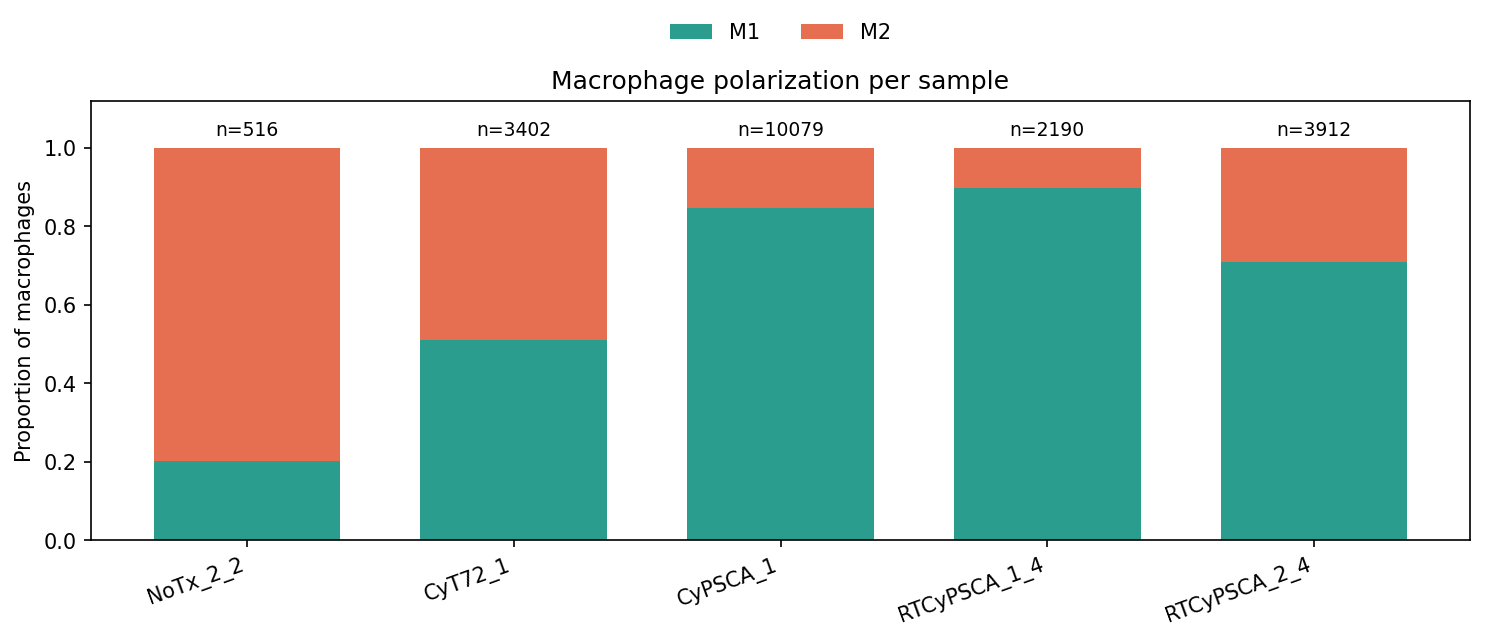

[Figure A] Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/Results/spp1_mac_analysis/final_analysi/mac_polarization_M1_vs_M2_100stack.png
Mac_polarization_tiered    M1    M2      N
sample_plot                               
NoTx_2_2                  104   412    516
CyT72_1                  1736  1666   3402
CyPSCA_1                 8541  1538  10079
RTCyPSCA_1_4             1965   225   2190
RTCyPSCA_2_4             2777  1135   3912


In [45]:
# === Figure A: M1 vs M2 100% stacked per sample (with N on top) ===
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 0) Output folder: reuse if already defined
_outdir = None
for name in ["outdir", "fig_out", "FIG_OUT", "FIG_DIR", "SAVE_DIR"]:
    if name in globals():
        _outdir = Path(globals()[name])
        break
if _outdir is None:
    _outdir = Path.cwd() / "figures"
_outdir.mkdir(parents=True, exist_ok=True)

# 1) Basic assumptions / columns
m1_label = "M1"
m2_label = "M2"
pol_col   = "Mac_polarization_tiered"   # adjust if yours differs
mouse_col = "mouse"

# 2) Keep only macrophages with explicit M1/M2 calls
is_mac = adata.obs[pol_col].isin([m1_label, m2_label])
df = adata.obs.loc[is_mac, [mouse_col, pol_col]].copy()

# 3) Map/merge the “averaged” groups by summing counts (weighted props)
sample_map = {
    "CyPSCA_1_1": "CyPSCA_1",
    "CyPSCA_1_2": "CyPSCA_1",
    "RTCyT72_2_1": "CyT72_1",
    "RTCyT72_2_4": "CyT72_1",
    "CyT72_1_4":     "CyT72_1",
}

df["sample_plot"] = df[mouse_col].map(sample_map).fillna(df[mouse_col])

# 4) Order
order = ["NoTx_2_2", "CyT72_1", "CyPSCA_1", "RTCyPSCA_1_4", "RTCyPSCA_2_4"]

# 5) Count table and proportions
ct = pd.crosstab(df["sample_plot"], df[pol_col]).reindex(order).fillna(0).astype(int)
# ensure both columns exist
for c in [m1_label, m2_label]:
    if c not in ct.columns:
        ct[c] = 0
ct = ct[[m1_label, m2_label]]
ct["N"] = ct.sum(axis=1)
props = ct[[m1_label, m2_label]].div(ct["N"].replace(0, np.nan), axis=0).fillna(0)

# 6) Plot
fig, ax = plt.subplots(figsize=(10, 4.5), dpi=150)

x = np.arange(len(order))
width = 0.7

# colors (distinct from LR-tier palette you use elsewhere)
col_m1 = "#2a9d8f"  # teal
col_m2 = "#e76f51"  # coral

bottom = np.zeros(len(order))
for k, col, label in zip([m1_label, m2_label], [col_m1, col_m2], [m1_label, m2_label]):
    vals = props[k].values
    ax.bar(x, vals, width, bottom=bottom, label=label, color=col)
    bottom += vals

# N labels above bars
for i, n in enumerate(ct["N"].values):
    ax.text(x[i], 1.02, f"n={n}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x, order, rotation=20, ha="right")
ax.set_ylim(0, 1.12)
ax.set_ylabel("Proportion of macrophages")
ax.set_title("Macrophage polarization per sample")
ax.legend(frameon=False, ncols=2, loc="upper center", bbox_to_anchor=(0.5, 1.22))

plt.tight_layout()
outpath = _outdir / "mac_polarization_M1_vs_M2_100stack.png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

print(f"[Figure A] Saved: {outpath}")
print(ct)  # quick summary of counts per bar


/tmp/ipykernel_11949/1718565355.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(sum_tiers)


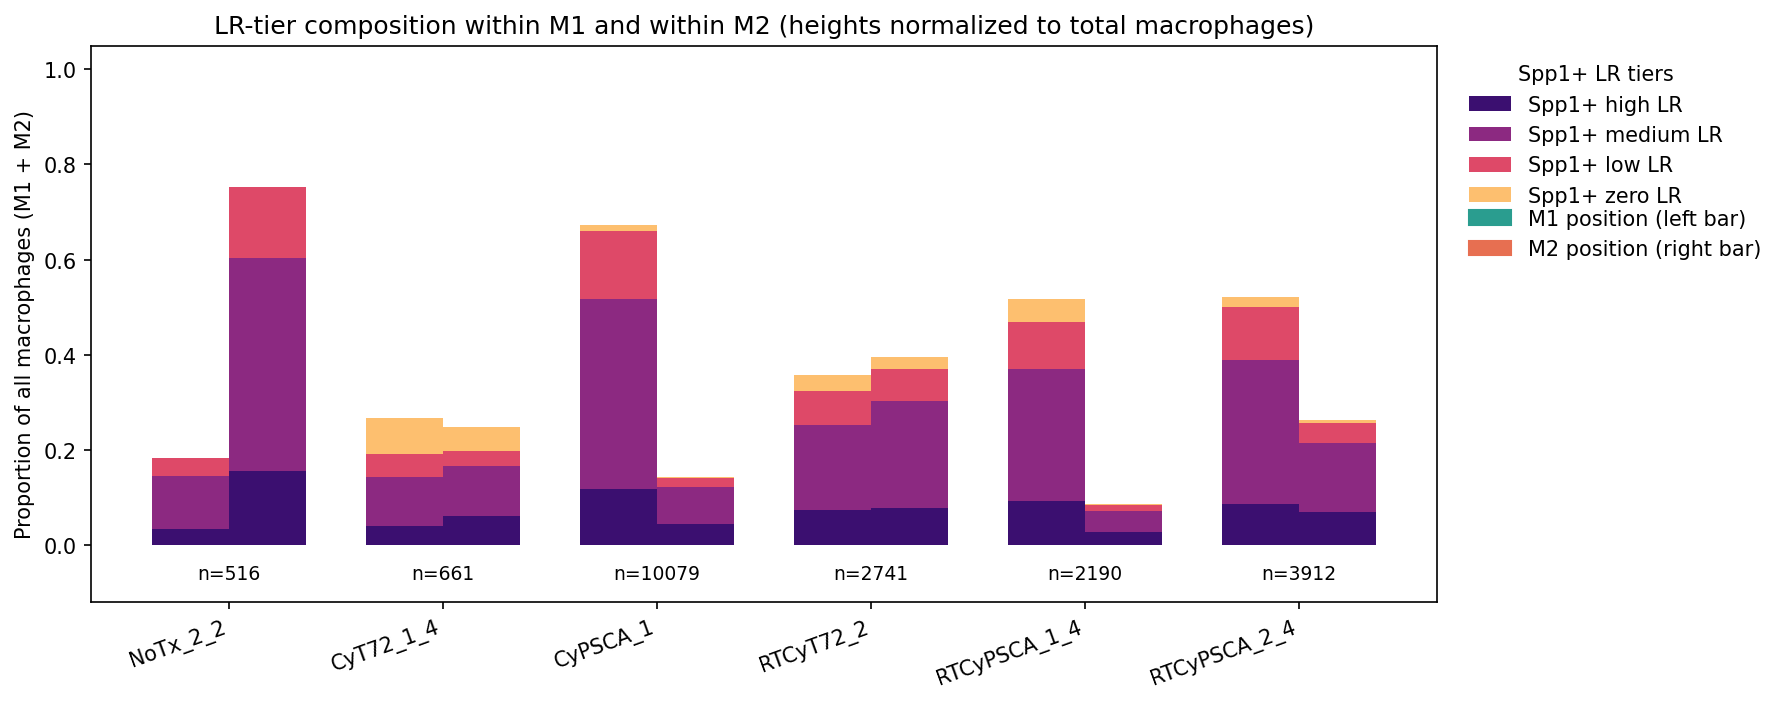

[Figure B] Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/Results/spp1_mac_analysis/final_analysi/mac_LRtiers_within_M1_M2_normalizedToTotal.png
              M1_fraction  M2_fraction  N_total
sample_plot                                    
NoTx_2_2            0.184        0.752      516
CyT72_1_4           0.266        0.248      661
CyPSCA_1            0.672        0.142    10079
RTCyT72_2           0.357        0.395     2741
RTCyPSCA_1_4        0.517        0.087     2190
RTCyPSCA_2_4        0.520        0.262     3912


In [33]:
# === Figure B (robust): Paired M1/M2 bars per sample, each stacked by LR tiers ===
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 0) Output folder: reuse if already defined
_outdir = None
for name in ["outdir", "fig_out", "FIG_OUT", "FIG_DIR", "SAVE_DIR"]:
    if name in globals():
        _outdir = Path(globals()[name])
        break
if _outdir is None:
    _outdir = Path.cwd() / "figures"
_outdir.mkdir(parents=True, exist_ok=True)

# 1) Labels/columns (match Cell A to avoid surprises)
m1_label = "M1"
m2_label = "M2"
pol_col   = "Mac_polarization_tiered"
mouse_col = "mouse"

# (re)define mapping + order here so Cell B is standalone
sample_map = {
    "CyPSCA_1_1": "CyPSCA_1",
    "CyPSCA_1_2": "CyPSCA_1",
    "RTCyT72_2_1": "CyT72_1",
    "RTCyT72_2_4": "CyT72_1",
    "CyT72_1_4":     "CyT72_1",
}
order = ["NoTx_2_2", "CyT72_1", "CyPSCA_1", "RTCyPSCA_1_4", "RTCyPSCA_2_4"]

# 2) Tier columns
tier_cols = {
    "Mac_Spp1pos_highLR": "Spp1+ high LR",
    "Mac_Spp1pos_medLR":  "Spp1+ medium LR",
    "Mac_Spp1pos_lowLR":  "Spp1+ low LR",
    "Mac_Spp1pos_zeroLR": "Spp1+ zero LR",
}
tier_keys   = list(tier_cols.keys())
tier_labels = [tier_cols[k] for k in tier_keys]

# Palette for LR tiers (high→zero)
tier_colors = ["#3b0f70", "#8c2981", "#de4968", "#fdbf6f"]

# 3) Subset to macrophages with M1/M2
is_mac = adata.obs[pol_col].isin([m1_label, m2_label])
use_cols = [mouse_col, pol_col] + [c for c in tier_keys if c in adata.obs.columns]
missing = set(tier_keys) - set(use_cols)
if missing:
    print(f"[warn] Missing LR tier columns in adata.obs: {missing}. Proceeding with available ones.")
df2 = adata.obs.loc[is_mac, use_cols].copy()

# 4) Merge samples (averaged groups become one label)
df2["sample_plot"] = df2[mouse_col].map(sample_map).fillna(df2[mouse_col])

# 5) Count matrix: for each (sample_plot x class) sum 1's in each tier column
def sum_tiers(sub):
    out = {}
    for k in tier_keys:
        if k in sub:
            out[k] = sub[k].astype(int).sum()
        else:
            out[k] = 0
    out["total_mac"] = len(sub)
    return pd.Series(out)

grouped = (
    df2.groupby(["sample_plot", pol_col], observed=True)
       .apply(sum_tiers)
       .reset_index()
)

# 6) Pivot to a consistent (class, tier) MultiIndex; fill any missing with 0
pivot = grouped.pivot(index="sample_plot", columns=pol_col, values=tier_keys)
# pivot columns come out as (tier, class) → swap to (class, tier)
pivot = pivot.swaplevel(0, 1, axis=1).sort_index(axis=1)

# enforce complete column grid and row order
full_cols = pd.MultiIndex.from_product([[m1_label, m2_label], tier_keys])
pivot = (pivot
         .reindex(order)                                   # enforce row order
         .reindex(columns=full_cols, fill_value=0)         # enforce full (class,tier) grid
        )

# 7) Total macrophages per sample (M1+M2) for normalization
N_total = df2.groupby("sample_plot").size().reindex(order).fillna(0).astype(int)

# 8) Plot: for each sample draw two adjacent bars (left=M1, right=M2),
#          heights = tier_count / total_macrophages_in_sample
fig, ax = plt.subplots(figsize=(12, 4.8), dpi=150)

x_base = np.arange(len(order))
bar_w  = 0.36
offset = [-bar_w/2, bar_w/2]  # M1 left, M2 right

for j, cls in enumerate([m1_label, m2_label]):
    bottoms = np.zeros(len(order))
    for k_idx, k in enumerate(tier_keys):
        counts  = pivot[(cls, k)].values.astype(float)
        heights = np.divide(counts, N_total.values, out=np.zeros_like(counts), where=N_total.values>0)
        ax.bar(x_base + offset[j], heights, bar_w, bottom=bottoms,
               color=tier_colors[k_idx], label=tier_cols[k] if j == 0 else None)
        bottoms += heights

# x-axis + n under ticks
ax.set_xticks(x_base, order, rotation=20, ha="right")
for i, n in enumerate(N_total.values):
    ax.text(x_base[i], -0.04, f"n={n}", ha="center", va="top", fontsize=9)

ax.set_ylim(-0.12, 1.05)
ax.set_ylabel("Proportion of all macrophages (M1 + M2)")
ax.set_title("LR-tier composition within M1 and within M2 (heights normalized to total macrophages)")

# legends
tier_legend = ax.legend(title="Spp1+ LR tiers", frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1.0))
ax.add_artist(tier_legend)
side_legend = [Patch(color="#2a9d8f", label="M1 position (left bar)"),
               Patch(color="#e76f51", label="M2 position (right bar)")]
ax.legend(handles=side_legend, frameon=False, loc="upper left", bbox_to_anchor=(1.01, 0.74))

plt.tight_layout()
outpath2 = _outdir / "mac_LRtiers_within_M1_M2_normalizedToTotal.png"
plt.savefig(outpath2, dpi=300, bbox_inches="tight")
plt.show()

print(f"[Figure B] Saved: {outpath2}")

# 9) Quick summary: fraction of M1/M2 per sample (should match Figure A fractions)
m1_frac = pivot[m1_label].sum(axis=1).div(N_total.replace(0, np.nan)).fillna(0)
m2_frac = pivot[m2_label].sum(axis=1).div(N_total.replace(0, np.nan)).fillna(0)
summary = pd.DataFrame({"M1_fraction": m1_frac, "M2_fraction": m2_frac, "N_total": N_total}).reindex(order)
print(summary.round(3))


# Stacked M1 and M2 

/tmp/ipykernel_11949/764972249.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_counts = df.groupby("sample_plot")[tier_keys].sum().reindex(order).fillna(0).astype(int)


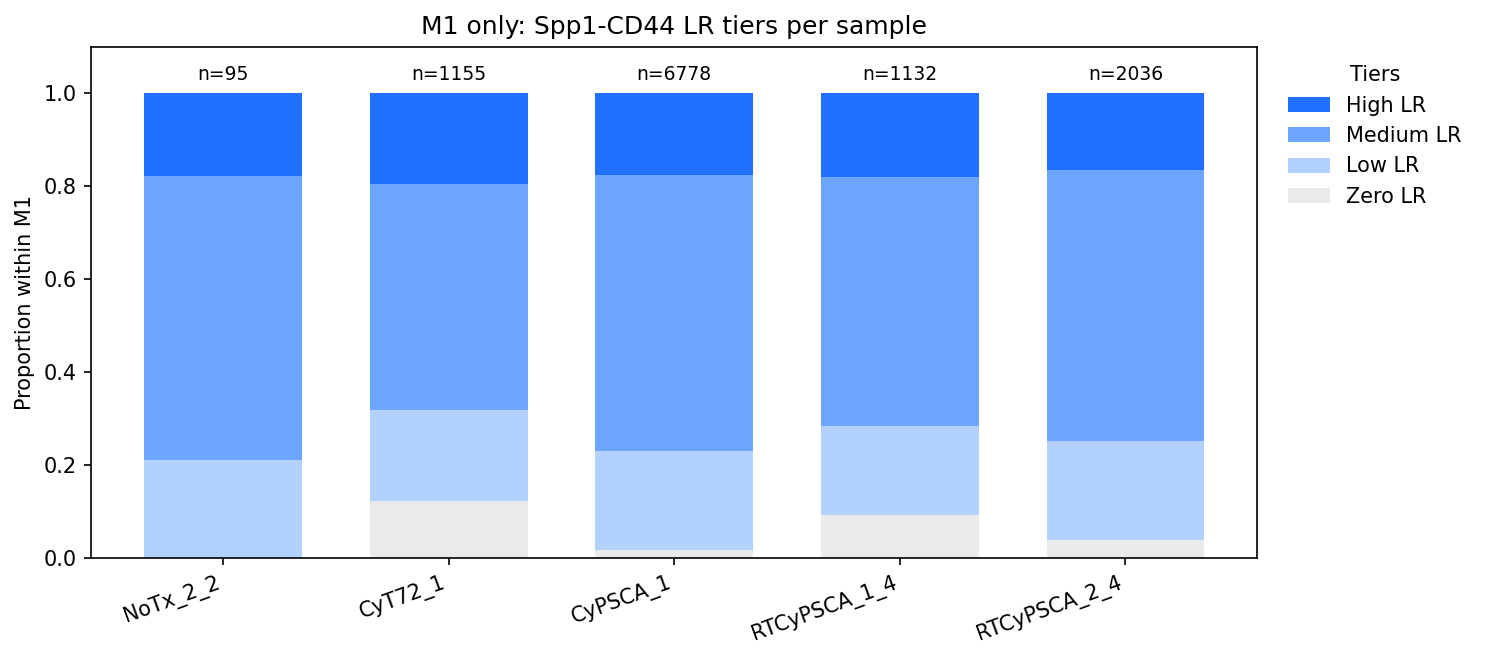

[Figure C] Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/Results/spp1_mac_analysis/final_analysi/mac_LRtiers_M1_only_100stack.png
sample_plot  NoTx_2_2  CyT72_1  CyPSCA_1  RTCyPSCA_1_4  RTCyPSCA_2_4
N_M1               95     1155      6778          1132          2036


In [46]:
# === Figure C: M1-only; Spp1+ LR tiers normalized to 1 per sample ===
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Output folder (reuse if defined earlier)
_outdir = None
for name in ["outdir", "fig_out", "FIG_OUT", "FIG_DIR", "SAVE_DIR"]:
    if name in globals():
        _outdir = Path(globals()[name])
        break
if _outdir is None:
    _outdir = Path.cwd() / "figures"
_outdir.mkdir(parents=True, exist_ok=True)

# Columns/labels (match your session)
mouse_col = "mouse"
pol_col   = "Mac_polarization_tiered"
m1_label  = "M1"
m2_label  = "M2"

# Averaging map + desired order
sample_map = {
    "CyPSCA_1_1": "CyPSCA_1",
    "CyPSCA_1_2": "CyPSCA_1",
    "RTCyT72_2_1": "CyT72_1",
    "RTCyT72_2_4": "CyT72_1",
    "CyT72_1_4":     "CyT72_1",
}
order = ["NoTx_2_2", "CyT72_1", "CyPSCA_1", "RTCyPSCA_1_4", "RTCyPSCA_2_4"]

# Tier columns (ensure these exist in adata.obs)
tier_cols = {
    "Mac_Spp1pos_zeroLR": "Zero LR",
    "Mac_Spp1pos_lowLR":  "Low LR",
    "Mac_Spp1pos_medLR":  "Medium LR",
    "Mac_Spp1pos_highLR": "High LR",
}
tier_keys   = list(tier_cols.keys())               # [zero, low, med, high] — stack bottom→top
tier_labels = [tier_cols[k] for k in tier_keys]

# Colorblind-friendly light→dark ramp (zero→high). Feel free to tweak.
tier_colors = ["#eaeaea", "#b3d1ff", "#6ea6ff", "#1f70ff"]

# Subset macrophages of class M1
is_m1 = adata.obs[pol_col].eq(m1_label)
use_cols = [mouse_col, pol_col] + [c for c in tier_keys if c in adata.obs.columns]
missing = set(tier_keys) - set(use_cols)
if missing:
    print(f"[warn] Missing LR tier columns in adata.obs: {missing}. Proceeding with available ones.")
df = adata.obs.loc[is_m1, use_cols].copy()

# Merge “averaged” groups and enforce order
df["sample_plot"] = df[mouse_col].map(sample_map).fillna(df[mouse_col])
df["sample_plot"] = pd.Categorical(df["sample_plot"], categories=order, ordered=True)

# Count tiers per sample
tier_counts = df.groupby("sample_plot")[tier_keys].sum().reindex(order).fillna(0).astype(int)
N_class = tier_counts.sum(axis=1)  # total M1 macrophages per sample

# Normalize within class (so each bar sums to 1)
props = tier_counts.div(N_class.replace(0, np.nan), axis=0).fillna(0)

# Plot
fig, ax = plt.subplots(figsize=(10, 4.5), dpi=150)
x = np.arange(len(order))
width = 0.7

bottom = np.zeros(len(order))
for k, label, color in zip(tier_keys, tier_labels, tier_colors):
    vals = props[k].values
    ax.bar(x, vals, width, bottom=bottom, label=label, color=color)
    bottom += vals

# n labels above bars
for i, n in enumerate(N_class.values):
    ax.text(x[i], 1.02, f"n={n}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x, order, rotation=20, ha="right")
ax.set_ylim(0, 1.1)
ax.set_ylabel("Proportion within M1")
ax.set_title("M1 only: Spp1-CD44 LR tiers per sample")
# Legend ordered top-down: High → Medium → Low → Zero
handles, labels = ax.get_legend_handles_labels()
# current order is [zero, low, med, high]; reverse for legend display
ax.legend(handles[::-1], labels[::-1], title="Tiers", frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1.0))

plt.tight_layout()
outpath = _outdir / "mac_LRtiers_M1_only_100stack.png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

print(f"[Figure C] Saved: {outpath}")
print(pd.DataFrame({"N_M1": N_class}).T)


/tmp/ipykernel_11949/83132659.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_counts = df.groupby("sample_plot")[tier_keys].sum().reindex(order).fillna(0).astype(int)


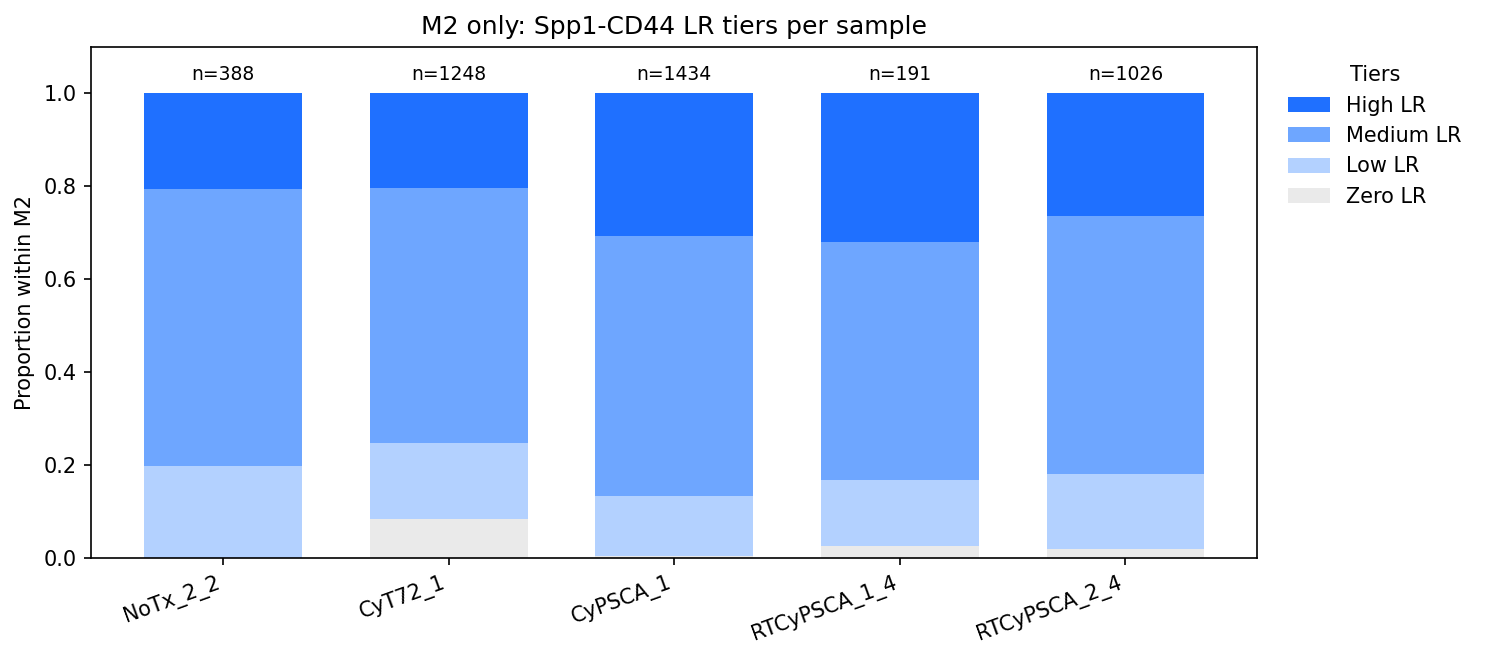

[Figure D] Saved: /mnt/c/Users/jonan/Documents/1Work/RoseLab/Spatial/CAR_T/Results/spp1_mac_analysis/final_analysi/mac_LRtiers_M2_only_100stack.png
sample_plot  NoTx_2_2  CyT72_1  CyPSCA_1  RTCyPSCA_1_4  RTCyPSCA_2_4
N_M2              388     1248      1434           191          1026


In [52]:
# === Figure D: M2-only; Spp1+ LR tiers normalized to 1 per sample ===
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Output folder (reuse if defined earlier)
_outdir = None
for name in ["outdir", "fig_out", "FIG_OUT", "FIG_DIR", "SAVE_DIR"]:
    if name in globals():
        _outdir = Path(globals()[name])
        break
if _outdir is None:
    _outdir = Path.cwd() / "figures"
_outdir.mkdir(parents=True, exist_ok=True)

# Columns/labels (match your session)
mouse_col = "mouse"
pol_col   = "Mac_polarization_tiered"
m1_label  = "M1"
m2_label  = "M2"

# Averaging map + desired order
sample_map = {
    "CyPSCA_1_1": "CyPSCA_1",
    "CyPSCA_1_2": "CyPSCA_1",
    "RTCyT72_2_1": "CyT72_1",
    "RTCyT72_2_4": "CyT72_1",
    "CyT72_1_4":     "CyT72_1",
}
order = ["NoTx_2_2", "CyT72_1", "CyPSCA_1", "RTCyPSCA_1_4", "RTCyPSCA_2_4"]

# Tier columns in desired stack order: zero→low→medium→high
tier_cols = {
    "Mac_Spp1pos_zeroLR": "Zero LR",
    "Mac_Spp1pos_lowLR":  "Low LR",
    "Mac_Spp1pos_medLR":  "Medium LR",
    "Mac_Spp1pos_highLR": "High LR",
}
tier_keys   = list(tier_cols.keys())
tier_labels = [tier_cols[k] for k in tier_keys]

# Same palette (zero→high)
tier_colors = ["#eaeaea", "#b3d1ff", "#6ea6ff", "#1f70ff"]

# Subset macrophages of class M2
is_m2 = adata.obs[pol_col].eq(m2_label)
use_cols = [mouse_col, pol_col] + [c for c in tier_keys if c in adata.obs.columns]
missing = set(tier_keys) - set(use_cols)
if missing:
    print(f"[warn] Missing LR tier columns in adata.obs: {missing}. Proceeding with available ones.")
df = adata.obs.loc[is_m2, use_cols].copy()

# Merge “averaged” groups and enforce order
df["sample_plot"] = df[mouse_col].map(sample_map).fillna(df[mouse_col])
df["sample_plot"] = pd.Categorical(df["sample_plot"], categories=order, ordered=True)

# Count tiers per sample
tier_counts = df.groupby("sample_plot")[tier_keys].sum().reindex(order).fillna(0).astype(int)
N_class = tier_counts.sum(axis=1)  # total M2 macrophages per sample

# Normalize within class
props = tier_counts.div(N_class.replace(0, np.nan), axis=0).fillna(0)

# Plot
fig, ax = plt.subplots(figsize=(10, 4.5), dpi=150)
x = np.arange(len(order))
width = 0.7

bottom = np.zeros(len(order))
for k, label, color in zip(tier_keys, tier_labels, tier_colors):
    vals = props[k].values
    ax.bar(x, vals, width, bottom=bottom, label=label, color=color)
    bottom += vals

# n labels above bars
for i, n in enumerate(N_class.values):
    ax.text(x[i], 1.02, f"n={n}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x, order, rotation=20, ha="right")
ax.set_ylim(0, 1.1)
ax.set_ylabel("Proportion within M2")
ax.set_title("M2 only: Spp1-CD44 LR tiers per sample")
# Legend displayed top-down: High → Medium → Low → Zero
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title="Tiers", frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1.0))

plt.tight_layout()
outpath = _outdir / "mac_LRtiers_M2_only_100stack.png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

print(f"[Figure D] Saved: {outpath}")
print(pd.DataFrame({"N_M2": N_class}).T)
